In [94]:
import pandas as pd
import json
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np
from collections import Counter
from scipy.spatial import distance 
from scipy.special import softmax
from scipy.stats import wasserstein_distance
import torch.nn.functional as F

## Useful Functions

In [13]:
def load_ndjson(data_path) -> list[dict]:

    """
    Loads ndjson files into memory as dictionaries.
    :param data_path: path to ndjson file
    :return: list of dictionaries
    """

    data = []
    with open(data_path, "r") as f:
        for line in f:
            if line.strip():  # avoid empty lines
                data.append(json.loads(line))

    return data

In [105]:
def get_internal_probs(measurements: list[dict]):
    
    """
    :param measurements: list of Measurement objects (or equivelant dictionaries)
    """
    
    # calculate probs from mean logits (should be all the same, though)
    internal_probs = softmax(np.mean([np.array(l['logits']) for l in measurements], axis=0))
    
    return internal_probs

In [106]:
def get_generation_probs(measurements: list[dict]):
    
    """
    
    :param measurements: list of Measurement objects (or equivelant dictionaries)
    """
    # pronoun set is determined by the first measurement
    pnouns = measurements[0]['context']['pronouns_2']
    
    # calculate empirical generation probabilities (remove anything not in the list of pronouns)
    generation_counter = Counter([l['measurement']['BLANK'] for l in measurements])
    generation_counter_clean = {k: generation_counter[k] for k in pnouns}
    num_valid_measurements = np.sum(list(generation_counter_clean.values()))
    generation_probs = np.array(list(generation_counter_clean.values()))/num_valid_measurements
    
    return generation_probs

In [107]:
def get_generation_logit_distortion(measurements: list[dict]):
    
    """
    Measure of the difference between the (deterministic) internal beliefs of a model and the (observed) generation
    frequency of those same tokens. 
    
    Distance is measured as L1 (Manhattan) Distance because this a discrete, unordered distribution.
    
    :param measurements: list of Measurement objects (or equivelant dictionaries)
    """
    
    internal_probs = get_internal_probs(measurements)
    generation_probs = get_generation_probs(measurements)
    
    # L1 distance of the two arrays 
    return distance.cityblock(internal_probs, generation_probs)

## Data Loading

In [4]:
DATA_DIR = Path("../../")

In [116]:
LLAMA32_PATH = DATA_DIR / "one_pronoun_measurements_Llama-3.2-1B-Instruct_0.5_p2.ndjson"
llama32 = load_ndjson(LLAMA32_PATH)

## Llama Testing

In [117]:
llama32[0], llama32[101]

({'index': 0,
  'context': {'sent_order': [0, 1],
   'pnoun_order': [None, 0],
   'sentence_1': None,
   'sentence_2': 'The technician told the customer that BLANK had completed the repair.',
   'pronouns_1': ['he', 'she'],
   'pronouns_2': ['he', 'she']},
  'measurement': {'BLANK': 'he'},
  'probabilities': None,
  'logits': [9.3203125, 9.15625]},
 {'index': 0,
  'context': {'sent_order': [0, 1],
   'pnoun_order': [None, 1],
   'sentence_1': None,
   'sentence_2': 'The technician told the customer that BLANK had completed the repair.',
   'pronouns_1': ['he', 'she'],
   'pronouns_2': ['he', 'she']},
  'measurement': {'BLANK': 'she'},
  'probabilities': None,
  'logits': [7.91015625, 10.6640625]})

In [118]:
llama32_10 = [c for c in llama32 if (c['index']==10)]

In [119]:
llama32_10_na_0_fwd = [c for c in llama32 if (c['index']==10) and 
                 (c['context']['sentence_1'] is None) and 
                 (c['context']['pnoun_order'] == [None, 0]) and
                    (c['context']['sent_order'] == [0, 1])]

In [120]:
llama32_10_na_0_fwd_probs = softmax(np.mean([np.array(l['logits']) for l in llama32_10_na_0_fwd], 
                                      axis=0))
llama32_10_na_0_fwd_probs

array([0.50455717, 0.49544283])

In [121]:
llama32_10_na_0_fwd[0]

{'index': 10,
 'context': {'sent_order': [0, 1],
  'pnoun_order': [None, 0],
  'sentence_1': None,
  'sentence_2': 'The customer asked to speak with the manager because BLANK wanted to fix the billing error quickly.',
  'pronouns_1': ['he', 'she'],
  'pronouns_2': ['he', 'she']},
 'measurement': {'BLANK': 'she'},
 'probabilities': None,
 'logits': [10.015625, 10.0703125]}

In [122]:
Counter([l['measurement']['BLANK'] for l in llama32_10_na_0_fwd])

Counter({'she': 190, 'he': 110})

In [123]:
#logits_llama32_10 = np.mean([np.array(l['logits']) for l in llama32_10], axis=0)
#softmax(logits_llama32_10)

In [124]:
get_generation_logit_distortion(llama32_10_na_0_fwd)

0.2757809976084712

In [125]:
llama32_10_na_1_fwd = [c for c in llama32 if (c['index']==10) and 
                 (c['context']['sentence_1'] is None) and 
                 (c['context']['pnoun_order'] == [None, 1]) and
                    (c['context']['sent_order'] == [0, 1])]

In [126]:
llama32_10_na_1_fwd_probs = softmax(np.mean([np.array(l['logits']) for l in llama32_10_na], 
                                      axis=0))
llama32_10_na_1_fwd_probs

array([0.15329549, 0.84670451])

In [127]:
get_generation_logit_distortion(llama32_10_na_1_fwd)

0.052046562360581125

In [128]:
# There are "more difficult configurations" for language models. 

In [129]:
wasserstein_distance(llama32_10_na_0_fwd_probs,llama32_10_na_1_fwd_probs)

0.342147341129742

## Figures

For each item, there are two different sentences which get a blank filled in. Which one of the blanks is the one filled is determined by the sentence order. Sometimes, it is only the sentence by itself. There is also the free variable of what order the pronouns are presented in. Therefor, there are three binary free variables, or six degrees of freedom _for each sentence in each item_. 

1. Whether there is a contextual sentence.
2. What is the order of the pronouns presented as options. 
3. If there is a contextual sentence, what the pronoun in that sentence is. 

We want to know how logits and generation probs vary with pronoun orders, with the addition of the contextual sentence, and with the pronoun in the contextual sentence. 

We also want to know how logits and generation probs vary.

It could additionally be interesting to consider what the whole logit span looks like and maybe even how many instances the model failed to answer correctly, backing up the idea that some of these contexts are "hard".

Additionally maybe interesting to look at how this varies between RP and not. 

In [130]:
# First we get a partition
def get_index(index: int,
              data: list[dict]) -> list[dict]:
    
    """
    """
    
    return [d for d in data if d['index']==index]

def get_sent_order(order: list[int],
                   data: list[dict]) -> list[dict]:
    
    """
    """
    
    return [d for d in data if d['context']['sent_order'] == order]

def get_single_sentences(data: list[dict]) -> list[dict]:
    
    """
    """
    
    return [d for d in data if d['context']['sentence_1'] == None]

def get_filled_pnoun(pnoun_index: str, 
                     data: list[dict]) -> list[dict]:
    """
    """
    
    return [d for d in data if d['context']['pnoun_order'][0] == d['context']['pronouns_1'][pnoun_index]]

def get_pnoun_order(pnoun_order_index: int, 
                    data: list[dict]) -> list[dict]:
    
    """
    """
    
    return [d for d in data if d['context']['pnoun_order'][1] == pnoun_order_index]

In [131]:
test_data = get_single_sentences(get_sent_order([1,0], get_index(11, llama32)))
test_data

[{'index': 11,
  'context': {'sent_order': [1, 0],
   'pnoun_order': [None, 0],
   'sentence_1': None,
   'sentence_2': 'The teenager confided in the therapist because BLANK seemed trustworthy.',
   'pronouns_1': ['he', 'she'],
   'pronouns_2': ['he', 'she']},
  'measurement': {'BLANK': 'he'},
  'probabilities': None,
  'logits': [9.453125, 10.0234375]},
 {'index': 11,
  'context': {'sent_order': [1, 0],
   'pnoun_order': [None, 0],
   'sentence_1': None,
   'sentence_2': 'The teenager confided in the therapist because BLANK seemed trustworthy.',
   'pronouns_1': ['he', 'she'],
   'pronouns_2': ['he', 'she']},
  'measurement': {'BLANK': 'she'},
  'probabilities': None,
  'logits': [9.453125, 10.0234375]},
 {'index': 11,
  'context': {'sent_order': [1, 0],
   'pnoun_order': [None, 0],
   'sentence_1': None,
   'sentence_2': 'The teenager confided in the therapist because BLANK seemed trustworthy.',
   'pronouns_1': ['he', 'she'],
   'pronouns_2': ['he', 'she']},
  'measurement': {'BLANK

In [132]:
get_generation_probs(test_data), get_internal_probs(test_data), get_generation_logit_distortion(test_data)

(array([0.21666667, 0.78333333]),
 array([0.16255721, 0.83744279]),
 0.10821890437517154)

Text(0, 0.5, 'Empirical Generation Probability')

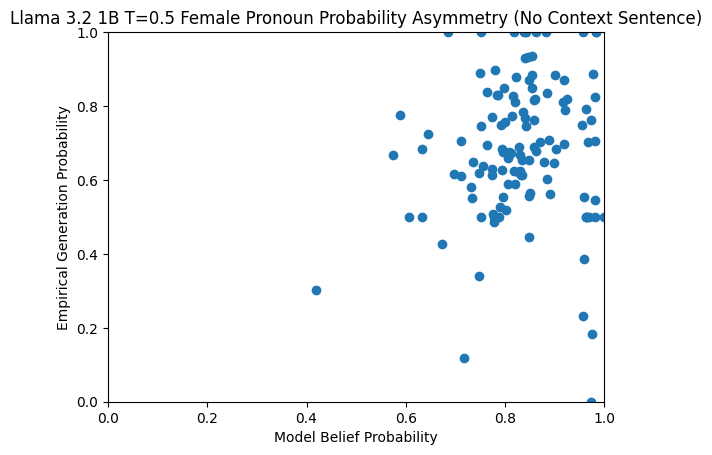

In [137]:
internal_generated_llama32 = []
for idx in range(60):
    d1 = get_single_sentences(get_sent_order([0,1], get_index(idx, llama32)))
    d2 = get_single_sentences(get_sent_order([1,0], get_index(idx, llama32)))
    
    internal_generated_llama32.append((get_internal_probs(d1)[1], get_generation_probs(d1)[1]))
    internal_generated_llama32.append((get_internal_probs(d2)[1], get_generation_probs(d2)[1]))
    
plt.scatter([i[0] for i in internal_generated_llama32], 
           [i[1] for i in internal_generated_llama32])

plt.ylim(0,1)
plt.xlim(0,1)
plt.title('Llama 3.2 1B T=0.5 Female Pronoun Probability Asymmetry (No Context Sentence)')
plt.xlabel('Model Belief Probability')
plt.ylabel('Empirical Generation Probability')

Text(0.5, 1.0, 'Distance Distribution Llama 3.2 1B')

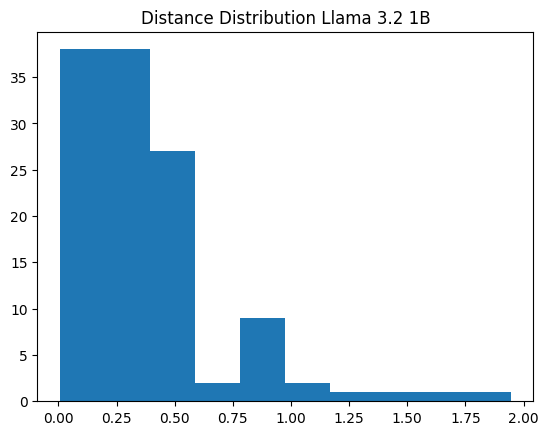

In [143]:
probability_distance_llama32 = []
for idx in range(60):
    d1 = get_single_sentences(get_sent_order([0,1], get_index(idx, llama32)))
    d2 = get_single_sentences(get_sent_order([1,0], get_index(idx, llama32)))
    
    probability_distance_llama32.append(get_generation_logit_distortion(d1))
    probability_distance_llama32.append(get_generation_logit_distortion(d2))
    
plt.hist(probability_distance_llama32, bins=10)

plt.title('Distance Distribution Llama 3.2 1B')

(array([46., 21., 20., 11., 16.,  5.,  0.,  0.,  0.,  1.]),
 array([3.60881738e-04, 7.50077492e-02, 1.49654617e-01, 2.24301484e-01,
        2.98948352e-01, 3.73595219e-01, 4.48242087e-01, 5.22888954e-01,
        5.97535822e-01, 6.72182689e-01, 7.46829557e-01]),
 <BarContainer object of 10 artists>)

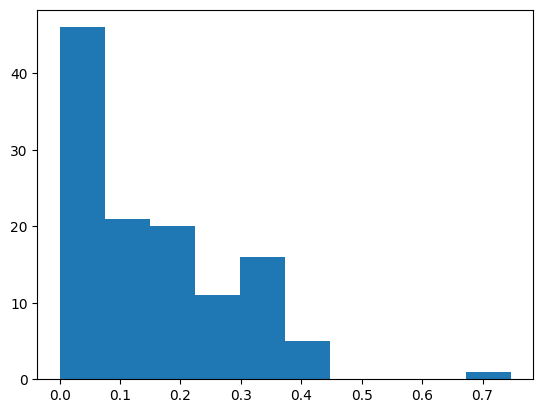

In [195]:
# Logit changes with context addition, m first
sent_orders = [[0,1], [1,0]]

llama_m_first_logit_changes = []
for idx in range(60):
    for order in sent_orders:
        none_sentence = get_single_sentences(get_sent_order(order, get_index(idx, llama32)))
        filled_sentence = get_filled_pnoun(0, get_sent_order(order, get_index(idx, llama32)))
        llama_m_first_logit_changes.append(distance.cityblock(
            get_internal_probs(none_sentence), 
            get_internal_probs(filled_sentence)))
        
plt.hist(llama_m_first_logit_changes, bins=10)

(array([46., 21., 20., 11., 16.,  5.,  0.,  0.,  0.,  1.]),
 array([3.60881738e-04, 7.50077492e-02, 1.49654617e-01, 2.24301484e-01,
        2.98948352e-01, 3.73595219e-01, 4.48242087e-01, 5.22888954e-01,
        5.97535822e-01, 6.72182689e-01, 7.46829557e-01]),
 <BarContainer object of 10 artists>)

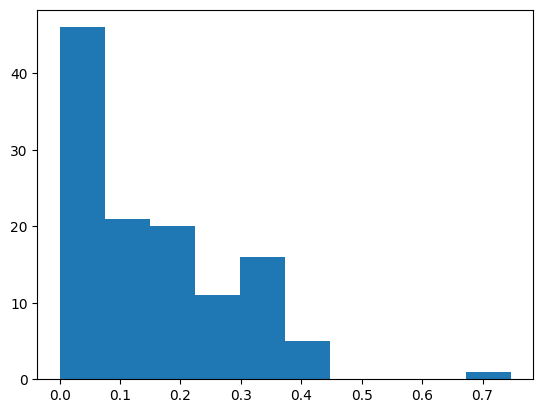

In [196]:
# Logit changes with context addition, m first
sent_orders = [[0,1], [1,0]]

llama_f_first_logit_changes = []
for idx in range(60):
    for order in sent_orders:
        none_sentence = get_single_sentences(get_sent_order(order, get_index(idx, llama32)))
        filled_sentence = get_filled_pnoun(1, get_sent_order(order, get_index(idx, llama32)))
        llama_f_first_logit_changes.append(distance.cityblock(
            get_internal_probs(none_sentence), 
            get_internal_probs(filled_sentence)))
        
plt.hist(llama_f_first_logit_changes, bins=10)

(0.0, 2.0)

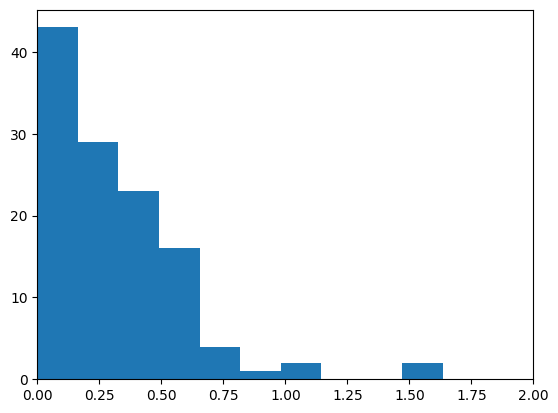

In [152]:
# Logit changes with context addition, m first
sent_orders = [[0,1], [1,0]]

llama_m_first_gen_changes = []
for idx in range(60):
    for order in sent_orders:
        none_sentence = get_single_sentences(get_sent_order(order, get_index(idx, llama32)))
        filled_sentence = get_filled_pnoun(0, get_sent_order(order, get_index(idx, llama32)))
        llama_m_first_gen_changes.append(distance.cityblock(
            get_generation_probs(none_sentence), 
            get_generation_probs(filled_sentence)))
        
plt.hist(llama_m_first_gen_changes, bins=10)
plt.xlim(0, 2)

(0.0, 2.0)

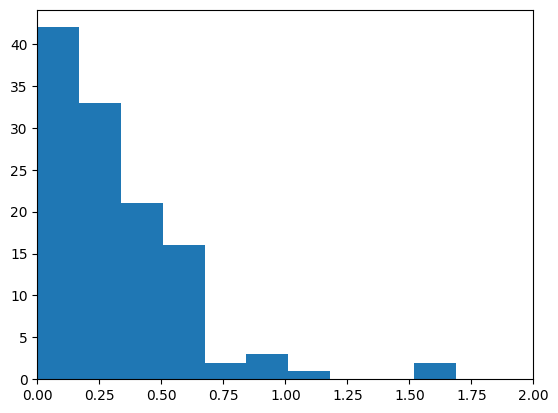

In [153]:
# Logit changes with context addition, m first
sent_orders = [[0,1], [1,0]]

llama_f_first_gen_changes = []
for idx in range(60):
    for order in sent_orders:
        none_sentence = get_single_sentences(get_sent_order(order, get_index(idx, llama32)))
        filled_sentence = get_filled_pnoun(1, get_sent_order(order, get_index(idx, llama32)))
        llama_f_first_gen_changes.append(distance.cityblock(
            get_generation_probs(none_sentence), 
            get_generation_probs(filled_sentence)))
        
plt.hist(llama_f_first_gen_changes, bins=10)
plt.xlim(0,2)

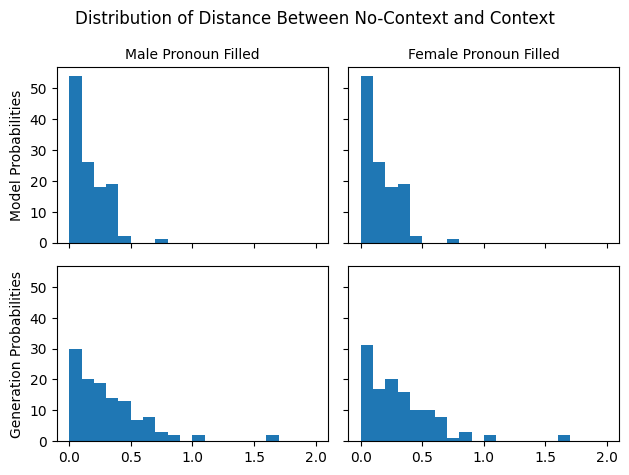

In [194]:
fig, axs = plt.subplots(2,2, sharey=True, sharex=True)
dist_bins = np.linspace(0,2,21)
axs[0,0].hist(llama_m_first_logit_changes, bins=dist_bins)
axs[0,1].hist(llama_f_first_logit_changes, bins=dist_bins)
axs[1,0].hist(llama_m_first_gen_changes, bins=dist_bins)
axs[1,1].hist(llama_f_first_gen_changes, bins=dist_bins)

axs[0,0].set_title('Male Pronoun Filled', fontsize=10)
axs[0,1].set_title('Female Pronoun Filled', fontsize=10)
axs[0,0].set_ylabel('Model Probabilities', )
axs[1,0].set_ylabel('Generation Probabilities')

fig.suptitle('Distribution of Distance Between No-Context and Context')
plt.tight_layout()

Text(0.5, 1.0, 'Llama 3.2 1B Model Probabilities')

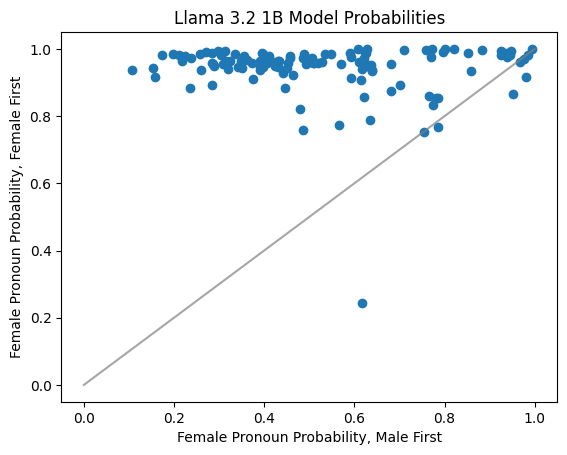

In [191]:
# Difference between forward and reverse pronoun order in unfilled sentences 

llama_fwd_none_model = []
llama_bwd_none_model = []

for idx in range(60):
    for order in sent_orders:
        fwd = get_pnoun_order(0, get_single_sentences(get_sent_order(order, get_index(idx, llama32))))
        bwd = get_pnoun_order(1, get_single_sentences(get_sent_order(order, get_index(idx, llama32))))
        
        
        llama_fwd_none_model.append(get_internal_probs(fwd)[1])
        llama_bwd_none_model.append(get_internal_probs(bwd)[1])
        
plt.scatter(llama_fwd_none_model, llama_bwd_none_model)
plt.plot(np.linspace(0,1,10), np.linspace(0,1,10), marker=None, color='gray', alpha=0.7)
plt.xlabel('Female Pronoun Probability, Male First')
plt.ylabel('Female Pronoun Probability, Female First')
plt.title('Llama 3.2 1B Model Probabilities')

/var/folders/ls/q83b082500j6d9zzb6gxmq0w0000gn/T/ipykernel_67305/2247140952.py:14: RuntimeWarning: invalid value encountered in divide
  generation_probs = np.array(list(generation_counter_clean.values()))/num_valid_measurements


Text(0.5, 1.0, 'Llama 3.2 1B Generation Probabilities')

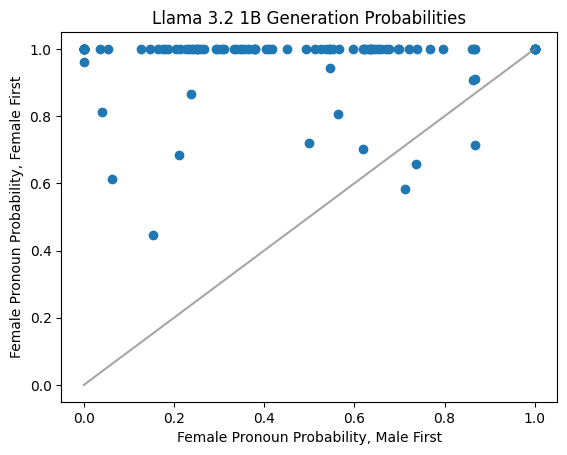

In [192]:
# Difference between forward and reverse pronoun order in unfilled sentences 

llama_fwd_none_gen = []
llama_bwd_none_gen = []

for idx in range(60):
    for order in sent_orders:
        fwd = get_pnoun_order(0, get_single_sentences(get_sent_order(order, get_index(idx, llama32))))
        bwd = get_pnoun_order(1, get_single_sentences(get_sent_order(order, get_index(idx, llama32))))
        
        llama_fwd_none_gen.append(get_generation_probs(fwd)[1])
        llama_bwd_none_gen.append(get_generation_probs(bwd)[1])
        
plt.scatter(llama_fwd_none_gen, llama_bwd_none_gen)
plt.plot(np.linspace(0,1,10), np.linspace(0,1,10), marker=None, color='gray', alpha=0.7)
plt.xlabel('Female Pronoun Probability, Male First')
plt.ylabel('Female Pronoun Probability, Female First')
plt.title('Llama 3.2 1B Generation Probabilities')

# Belief Contextuality

**Hold up** Can't I also get the probabilities for the first pronoun through the logits?? I guess I would run into the same issue regarding whether or not it would resolve the correct pronoun. 

In [270]:
# Super messy and unintuitive code, but should work

def cbd_expectation(px: float):

    """
    Returns the expectation value of a random variable, given its marginal probability (as per Dzhafarov)
    :param px: marginal probability
    :return: expectation value
    """
    return 2*px - 1

def cbd_correlation(px: float,
                    py: float,
                    pxy: float):
    """
    Returns the correlation of two random variables, given their marginals and joint (as per Dzhafarov)
    :param px: marginal probability of X
    :param py: marginal probability of Y
    :param pxy: joint probability
    :return:
    """
    return 4*pxy - 2*px - 2*py + 1


# Sentence-order contextuality via CBD
def sentence_order_results_internal(idx: int,
                                    model_measurements: list[dict],
                                    pnoun_order: list[int] = ['he', 0],
                                    default_pronoun: int = 1  # 0 for male, 1 for female
                                   ) -> dict:
    """
    Creates a dictionary given a subset of measurements for a single pair of sentences which summarizes the results of
    all runs, separated on the basis of sentence order, filtered for only one pronoun order.

    :param idx: integer index sentence pair
    :param model_measurements: list of Measurement objects (or equivalently structured dictionaries)
    :param pnoun_order: filtered pronoun order
    :param default_pronoun: pronoun index for probabiity calculations (default = 1 for female)
    :return:
    """
    sentence_measurements = [d for d in model_measurements if d['index'] == idx]
    test_measurements = [d for d in sentence_measurements if d['context']['pnoun_order'] == pnoun_order]

    data_dict = {'forward': {'fixed_pnoun': [], 'free_pnoun': [], 'pronouns': []},
                 'reverse': {'fixed_pnoun': [], 'free_pnoun': [], 'pronouns': []}}

    for d in test_measurements:
        
        context = d['context']['sent_order'] 
            
        if context == [0, 1]:
            dict_key = 'forward'
            fixed_pnoun = d['context']['pnoun_order'][0]
            free_pnoun = d['logits']
            default_p1 = d['context']['pronouns_1'][default_pronoun]
            default_p2 = d['context']['pronouns_2'][default_pronoun]
        elif context == [1, 0]:
            dict_key = 'reverse'
            fixed_pnoun = d['context']['pnoun_order'][0]
            free_pnoun = d['logits']
            default_p1 = d['context']['pronouns_2'][default_pronoun]
            default_p2 = d['context']['pronouns_1'][default_pronoun]
        else:
            raise AttributeError

        data_dict[dict_key]['fixed_pnoun'].append(fixed_pnoun.lower())
        data_dict[dict_key]['free_pnoun'].append(free_pnoun)
        data_dict[dict_key]['pronouns'] = [default_p1, default_p2]

    return data_dict

def calculate_sentence_nc_fraction_internal(data_dict: dict) -> float:

    """
    Calculates noncontextual fraction based on the output from sentence_order_results()
    
    :param data_dict: output of sentence_order_results()
    :return: noncontextual fraction
    """
    C1_size = len(data_dict['forward']['fixed_pnoun'])
    C2_size = len(data_dict['reverse']['fixed_pnoun'])

    V1_dict = Counter(data_dict['forward']['fixed_pnoun'])
    W2 = softmax(np.mean(data_dict['forward']['free_pnoun'], axis=0))
    W1 = softmax(np.mean(data_dict['reverse']['free_pnoun'], axis=0))
    V2_dict = Counter(data_dict['reverse']['fixed_pnoun'])

    try:  
        target_f = data_dict['forward']['pronouns']
        target_r = data_dict['reverse']['pronouns']
        
    

        V1 = V1_dict.get(target_f[0], 0) / C1_size
        W2 = W2[1]
        W1 = W1[1]
        V2 = V2_dict.get(target_r[1], 0) / C2_size
        
    except IndexError:
        print((idx, data_dict))

    # Compute joint probabilities
    ## p(x,y) = p(y|x)p(x)
    forward_trials = zip(data_dict['forward']['fixed_pnoun'], data_dict['forward']['free_pnoun'])
    count_c1 = sum(1 for x, y in forward_trials if x == target_f[0] and y == target_f[1])
    V1W2 = count_c1 / C1_size

    reverse_trials = zip(data_dict['reverse']['fixed_pnoun'], data_dict['reverse']['free_pnoun'])
    count_c2 = sum(1 for x, y in reverse_trials if x == target_r[0] and y == target_r[1])
    V2W1 = count_c2 / C2_size

    delta_c = (
            abs(cbd_correlation(V1, V2, V1W2) - cbd_correlation(V2, W1, V2W1))
            - (abs(cbd_expectation(V1) - cbd_expectation(W1))
               + abs(cbd_expectation(V2) - cbd_expectation(W2)))
    )

    return delta_c

In [271]:
forward_model = []
for idx in range(60):
    data_dict_idx = sentence_order_results_internal(idx, llama32)
    forward_model.append(calculate_sentence_nc_fraction_internal(data_dict_idx))

(1, {'forward': {'fixed_pnoun': [], 'free_pnoun': [], 'pronouns': []}, 'reverse': {'fixed_pnoun': ['he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he', 'he'], 'free_pnoun': [[5.91015625, 7.20703125], [5.91015625, 7.20703125], [5.91015625, 7.20703125], [5.91015625, 7.20703125], [5.91015625, 7.20703125], [5.91015625, 7.20703125], [5.91015625, 7.20703125], [5.91015625, 7.20703125], [5.91015625, 7.20703125], [5.91015625, 7.20703125], [5.91015625, 7.20703125],

ZeroDivisionError: division by zero

In [223]:
sentence_order_results_internal(0, llama32)

{'forward': {'fixed_pnoun': [], 'free_pnoun': [], 'pronouns': []},
 'reverse': {'fixed_pnoun': [], 'free_pnoun': [], 'pronouns': []}}

In [224]:
data_dict_idx

{'forward': {'fixed_pnoun': [], 'free_pnoun': [], 'pronouns': []},
 'reverse': {'fixed_pnoun': [], 'free_pnoun': [], 'pronouns': []}}

In [294]:
[d for d in llama32 if d['index']==2 and d['context']['pnoun_order']==['he',0] and 
 d['context']['sent_order']==[0,1]]

[]

In [295]:
[d for d in llama32 if d['index']==2 and d['context']['pnoun_order']==['he',0] and 
 d['context']['sent_order']==[1,0]]

[]

In [297]:
[d for d in llama32 if d['index']==2 and d['context']['pnoun_order']==['he',0]]

[]